In [1]:
import pyodbc as odbc
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split

In [3]:
from sqlalchemy import create_engine
import pandas as pd
import urllib

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=NILADRI\\SQLEXPRESS;"
    "DATABASE=AdventureWorks2019;"
    "Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

df = pd.read_sql("SELECT * FROM Sales.CustomerChurnPredictionFeature", engine)
print(df.shape)
print(df.head())
df.to_csv('Customer_Churn_SQL_Dataset.csv')

(19119, 14)
   CustomerID  DaysSinceLastOrder  CustomerTenure  AvgOrderValue  \
0       11000                 270            1105    2749.663333   
1       11001                  49            1109    2127.960000   
2       11002                 339            1117    2704.680000   
3       11003                 263            1126    2713.096666   
4       11004                 272            1101    2732.003333   

   TotalRevenue  OrderFrequency LeastRecentOrderDate MostRecentOrderDate  \
0       8248.99               3           2011-06-21          2013-10-03   
1       6383.88               3           2011-06-17          2014-05-12   
2       8114.04               3           2011-06-09          2013-07-26   
3       8139.29               3           2011-05-31          2013-10-10   
4       8196.01               3           2011-06-25          2013-10-01   

   TotalProductSubCategories MostPurchasedCategory  AvgDaysBetweenOrders  \
0                          6                 B

In [3]:
# unique values present in the dataset
print(df.nunique())

CustomerID                   19119
DaysSinceLastOrder             743
CustomerTenure                1124
AvgOrderValue                 5391
TotalRevenue                  5281
OrderFrequency                  17
LeastRecentOrderDate          1124
MostRecentOrderDate            743
TotalProductSubCategories       29
MostPurchasedCategory            4
AvgDaysBetweenOrders          1012
RecencyRatio                  6427
OneTimeBuyer                     2
ChurnLabel                       2
dtype: int64


In [4]:
print(df.isnull().sum())

CustomerID                       0
DaysSinceLastOrder               0
CustomerTenure                   0
AvgOrderValue                    0
TotalRevenue                     0
OrderFrequency                   0
LeastRecentOrderDate             0
MostRecentOrderDate              0
TotalProductSubCategories        0
MostPurchasedCategory            0
AvgDaysBetweenOrders         11649
RecencyRatio                 11654
OneTimeBuyer                     0
ChurnLabel                       0
dtype: int64


In [5]:
# check for null value summation 
print(df.isnull().sum().sum())

23303


In [6]:
# check the duplicate value summation in the dataset
print(df.duplicated().sum())

0


In [7]:
# basic statistics check
print(df.describe())

         CustomerID  DaysSinceLastOrder  CustomerTenure  AvgOrderValue  \
count  19119.000000        19119.000000    19119.000000   19119.000000   
mean   20559.000000          190.267483      358.822323    1505.502912   
min    11000.000000            0.000000        0.000000       1.374000   
25%    15779.500000           85.000000      145.000000      41.475000   
50%    20559.000000          165.000000      278.000000     548.980000   
75%    25338.500000          263.000000      502.000000    1948.266250   
max    30118.000000         1126.000000     1126.000000  133739.069650   
std     5519.324234          150.423605      285.321067    5348.756357   

        TotalRevenue  OrderFrequency           LeastRecentOrderDate  \
count   19119.000000    19119.000000                          19119   
mean     5745.404122        1.645745  2013-07-06 04:15:51.263141376   
min         1.374000        1.000000            2011-05-31 00:00:00   
25%        54.980000        1.000000            2

In [8]:
# class balance check
df['ChurnLabel'].value_counts()

ChurnLabel
0    10354
1     8765
Name: count, dtype: int64

In [9]:
df.dtypes

CustomerID                            int64
DaysSinceLastOrder                    int64
CustomerTenure                        int64
AvgOrderValue                       float64
TotalRevenue                        float64
OrderFrequency                        int64
LeastRecentOrderDate         datetime64[ns]
MostRecentOrderDate          datetime64[ns]
TotalProductSubCategories             int64
MostPurchasedCategory                object
AvgDaysBetweenOrders                float64
RecencyRatio                        float64
OneTimeBuyer                          int64
ChurnLabel                            int64
dtype: object

In [10]:
df.head(5)

,CustomerID,DaysSinceLastOrder,CustomerTenure,AvgOrderValue,TotalRevenue,OrderFrequency,LeastRecentOrderDate,MostRecentOrderDate,TotalProductSubCategories,MostPurchasedCategory,AvgDaysBetweenOrders,RecencyRatio,OneTimeBuyer,ChurnLabel
0,11000,270,1105,2749.663333,8248.99,3,2011-06-21,2013-10-03,6,Bikes,417.0,0.647482,0,1
1,11001,49,1109,2127.960000,6383.88,3,2011-06-17,2014-05-12,7,Bikes,530.0,0.092453,0,0
2,11002,339,1117,2704.680000,8114.04,3,2011-06-09,2013-07-26,3,Bikes,389.0,0.871465,0,1
3,11003,263,1126,2713.096666,8139.29,3,2011-05-31,2013-10-10,5,Bikes,431.0,0.610209,0,1
4,11004,272,1101,2732.003333,8196.01,3,2011-06-25,2013-10-01,4,Bikes,414.0,0.657005,0,1


In [11]:
# unnecessary columns drop
df=df.drop(columns=['CustomerID','LeastRecentOrderDate','MostRecentOrderDate'],axis = 1)
df.shape

(19119, 11)

In [12]:
df.MostPurchasedCategory.value_counts()

MostPurchasedCategory
Accessories    9309
Bikes          7619
Clothing       2002
Components      189
Name: count, dtype: int64

In [13]:
# converting the categorical values of the mostpuchasedcategory column to numerical values using label encoder
le = LabelEncoder()
df['MostPurchasedCategory'] = le.fit_transform(df['MostPurchasedCategory'])
print(df.MostPurchasedCategory.value_counts())

MostPurchasedCategory
0    9309
1    7619
2    2002
3     189
Name: count, dtype: int64


In [14]:
df.columns.to_list()

['DaysSinceLastOrder',
 'CustomerTenure',
 'AvgOrderValue',
 'TotalRevenue',
 'OrderFrequency',
 'TotalProductSubCategories',
 'MostPurchasedCategory',
 'AvgDaysBetweenOrders',
 'RecencyRatio',
 'OneTimeBuyer',
 'ChurnLabel']

In [15]:
print("Description of the dataset: \n", df.describe())

Description of the dataset: 
        DaysSinceLastOrder  CustomerTenure  AvgOrderValue   TotalRevenue  \
count        19119.000000    19119.000000   19119.000000   19119.000000   
mean           190.267483      358.822323    1505.502912    5745.404122   
std            150.423605      285.321067    5348.756357   38800.383347   
min              0.000000        0.000000       1.374000       1.374000   
25%             85.000000      145.000000      41.475000      54.980000   
50%            165.000000      278.000000     548.980000     548.980000   
75%            263.000000      502.000000    1948.266250    2822.386050   
max           1126.000000     1126.000000  133739.069650  877107.192221   

       OrderFrequency  TotalProductSubCategories  MostPurchasedCategory  \
count    19119.000000               19119.000000           19119.000000   
mean         1.645745                   2.644176               0.637586   
std          1.457054                   2.107409               0.7069

In [16]:
print("Skewness of the dataset: \n", df.skew())
print("Kurtosis of the dataset: ", df.kurtosis())

Skewness of the dataset: 
 DaysSinceLastOrder            2.435350
CustomerTenure                1.040590
AvgOrderValue                10.812370
TotalRevenue                 12.798424
OrderFrequency                7.388770
TotalProductSubCategories     4.834833
MostPurchasedCategory         0.814872
AvgDaysBetweenOrders          0.696193
RecencyRatio                 22.204662
OneTimeBuyer                 -0.448025
ChurnLabel                    0.166812
dtype: float64
Kurtosis of the dataset:  DaysSinceLastOrder             9.990896
CustomerTenure                 0.121439
AvgOrderValue                143.709653
TotalRevenue                 193.666775
OrderFrequency                89.645344
TotalProductSubCategories     35.824939
MostPurchasedCategory          0.026721
AvgDaysBetweenOrders          -0.332496
RecencyRatio                 655.759223
OneTimeBuyer                  -1.799462
ChurnLabel                    -1.972380
dtype: float64


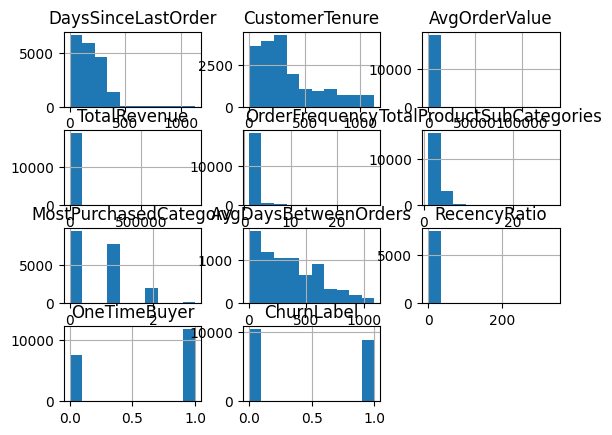

<Figure size 2000x800 with 0 Axes>

In [17]:

df.hist()
plt.figure(figsize=(20,8))
plt.show()

In [18]:
# fill avgdaysbetween orders with 0 instead of null for one time buyers
df['AvgDaysBetweenOrders'] = df['AvgDaysBetweenOrders'].fillna(0)
df.isnull().sum()

DaysSinceLastOrder               0
CustomerTenure                   0
AvgOrderValue                    0
TotalRevenue                     0
OrderFrequency                   0
TotalProductSubCategories        0
MostPurchasedCategory            0
AvgDaysBetweenOrders             0
RecencyRatio                 11654
OneTimeBuyer                     0
ChurnLabel                       0
dtype: int64

In [19]:
# for one time buyers , recency ratio is high showing they are the most overdue customers in the dataset....so fill the null values with max values
df['RecencyRatio'] = df['RecencyRatio'].fillna(df['RecencyRatio'].max())
df.isnull().sum()

DaysSinceLastOrder           0
CustomerTenure               0
AvgOrderValue                0
TotalRevenue                 0
OrderFrequency               0
TotalProductSubCategories    0
MostPurchasedCategory        0
AvgDaysBetweenOrders         0
RecencyRatio                 0
OneTimeBuyer                 0
ChurnLabel                   0
dtype: int64

In [20]:
df['RecencyRatio']

0        0.647482
1        0.092453
2        0.871465
3        0.610209
4        0.657005
           ...   
19114    1.329670
19115    1.000000
19116    1.329670
19117    1.000000
19118    0.659341
Name: RecencyRatio, Length: 19119, dtype: float64

In [21]:
df['AvgDaysBetweenOrders']

0        417.0
1        530.0
2        389.0
3        431.0
4        414.0
         ...  
19114     91.0
19115     91.0
19116     91.0
19117     91.0
19118     91.0
Name: AvgDaysBetweenOrders, Length: 19119, dtype: float64

In [22]:
# pearson correlation check
import scipy.stats as pearson
corr_coeff, p_value = pearson.pearsonr(df['RecencyRatio'], df['AvgDaysBetweenOrders'])
print("Pearson Correlation Coefficient:", corr_coeff)   
print("P-value:", p_value)

if corr_coeff > 0:
    print("There is a positive correlation between RecencyRatio and AvgDaysBetweenOrders.")
elif corr_coeff < 0:
    print("There is a negative correlation between RecencyRatio and AvgDaysBetweenOrders.")
else:
    print("There is no correlation between RecencyRatio and AvgDaysBetweenOrders.")



Pearson Correlation Coefficient: -0.738327886588034
P-value: 0.0
There is a negative correlation between RecencyRatio and AvgDaysBetweenOrders.


                           DaysSinceLastOrder  CustomerTenure  AvgOrderValue  \
DaysSinceLastOrder                   1.000000        0.380459       0.055512   
CustomerTenure                       0.380459        1.000000       0.272043   
AvgOrderValue                        0.055512        0.272043       1.000000   
TotalRevenue                        -0.012581        0.214672       0.901030   
OrderFrequency                      -0.136708        0.417580       0.419315   
TotalProductSubCategories           -0.170697        0.325440       0.621359   
MostPurchasedCategory                0.070567        0.348990       0.214807   
AvgDaysBetweenOrders                -0.125294        0.782591       0.086999   
RecencyRatio                         0.163184       -0.655534      -0.216073   
OneTimeBuyer                         0.160870       -0.652927      -0.215807   
ChurnLabel                           0.707216        0.224314      -0.040450   

                           TotalRevenue

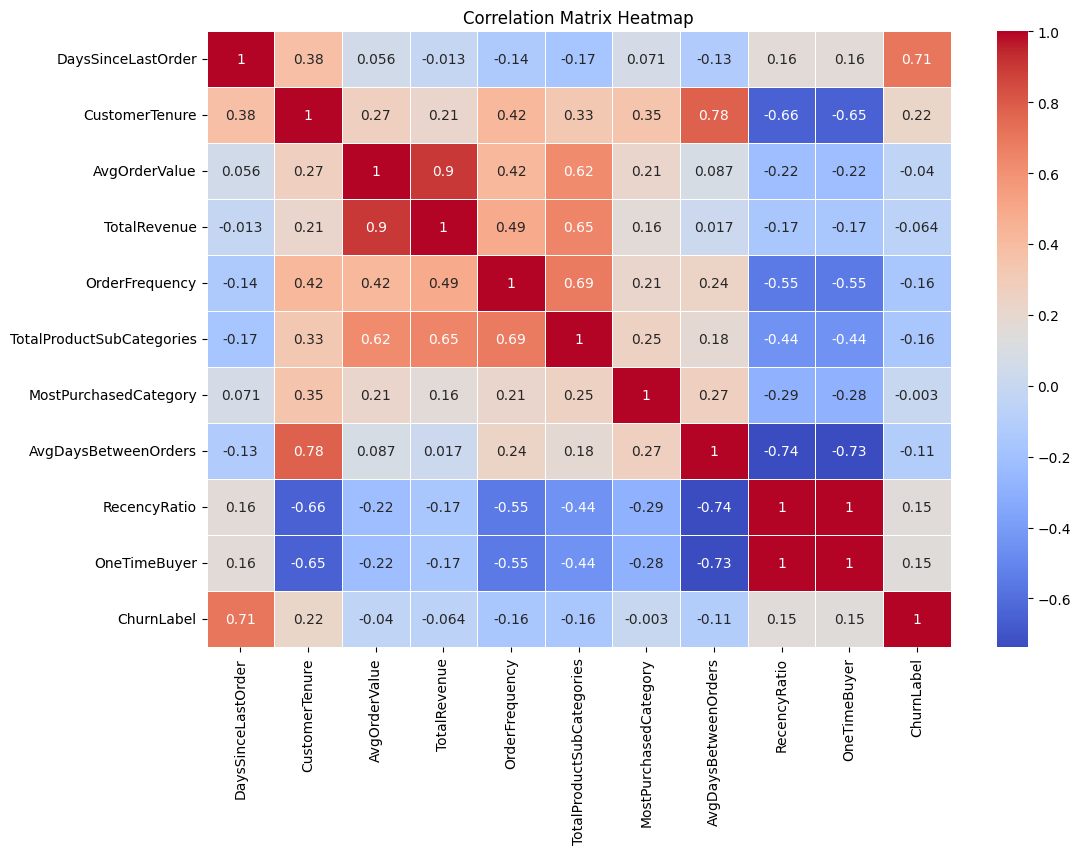

In [23]:
correlation_matrix = df.corr()
print(correlation_matrix)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [24]:
# drop the columns that have high correlation with each other to avoid multicollinearity
df = df.drop(columns = ['DaysSinceLastOrder' , 'OneTimeBuyer' , 'AvgOrderValue'],axis =1)

In [25]:
df.head(1)

,CustomerTenure,TotalRevenue,OrderFrequency,TotalProductSubCategories,MostPurchasedCategory,AvgDaysBetweenOrders,RecencyRatio,ChurnLabel
0,1105,8248.99,3,6,1,417.0,0.647482,1


In [26]:
df.shape

(19119, 8)

In [27]:
# Apply log transformation to highly skewed features to reduce skewness and make the data more normally distributed
skewed_features = ['RecencyRatio', 'TotalRevenue' ,'OrderFrequency']
df[skewed_features] = np.log1p(df[skewed_features])

In [28]:

print("Skewness of the dataset after log transformation: \n", df.skew())

Skewness of the dataset after log transformation: 
 CustomerTenure               1.040590
TotalRevenue                 0.140328
OrderFrequency               2.197602
TotalProductSubCategories    4.834833
MostPurchasedCategory        0.814872
AvgDaysBetweenOrders         1.793872
RecencyRatio                -0.497763
ChurnLabel                   0.166812
dtype: float64


In [29]:
# Define the independent variable (X) and the dependent variable (Y)
X = df[['RecencyRatio', 'TotalRevenue' ,'OrderFrequency' , 'TotalProductSubCategories', 'MostPurchasedCategory',
                             'AvgDaysBetweenOrders','CustomerTenure']]
Y = df['ChurnLabel']

In [30]:
# Print the shapes of X and Y to verify the dimensions
print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (19119, 7)
Shape of Y: (19119,)


In [31]:
X.head()

,RecencyRatio,TotalRevenue,OrderFrequency,TotalProductSubCategories,MostPurchasedCategory,AvgDaysBetweenOrders,CustomerTenure
0,0.499248,9.017967,1.386294,6,1,417.0,1105
1,0.088425,8.761688,1.386294,7,1,530.0,1109
2,0.626722,9.001474,1.386294,3,1,389.0,1117
3,0.476364,9.004581,1.386294,5,1,431.0,1126
4,0.505012,9.011525,1.386294,4,1,414.0,1101


In [32]:
# Divide the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=42)
#Print the shapes of the training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (15295, 7)
Shape of Y_train: (15295,)
Shape of X_test: (3824, 7)
Shape of Y_test: (3824,)


In [33]:
df['ChurnLabel'].value_counts()

ChurnLabel
0    10354
1     8765
Name: count, dtype: int64

<Axes: >

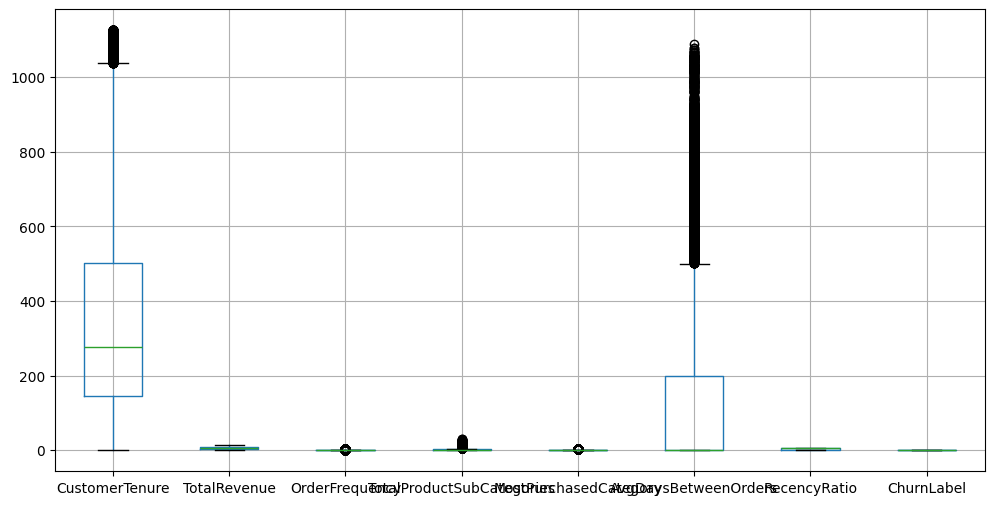

In [34]:
# check outliers using boxplot
df.boxplot(figsize=(12,6))

In [35]:
# save this processed dataset to a csv file and joblib for future use

import joblib
df.to_csv("customer_churn_processed_eda.csv", index=False)
joblib.dump(df, "customer_churn_processed_eda.joblib")

['customer_churn_processed_eda.joblib']